In [2]:
import geopandas as gpd
from shapely.geometry import Point, MultiPoint, LineString, MultiLineString
from shapely.ops import split
from geopy.distance import geodesic
import pandas as pd
import os
import re
import networkx as nx
from shapely.geometry import Point, LineString, MultiPolygon, Polygon
from shapely.ops import unary_union # For distance calc
from pyproj import Geod, CRS, Transformer # For distance calc projection
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.sample import sample_gen
import numpy as np
import math
import logging
from contextlib import contextmanager
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
import time
from geopy.geocoders import MapBox
from geopy.exc import GeocoderTimedOut, GeocoderServiceError
from tqdm.notebook import tqdm
from dotenv import load_dotenv
import pickle
import requests # Not used currently
import json # Not used currently
#Import required packages and modules
#import qgis
import PyQt5
from aequilibrae import Graph, AequilibraeMatrix, TrafficClass, TrafficAssignment
from aequilibrae.matrix import AequilibraeMatrix
from aequilibrae.paths import Graph
from aequilibrae.paths import TrafficAssignment
from aequilibrae.paths.traffic_class import TrafficClass
#from qgis.core import QgsVectorLayer, QgsField, QgsFeature, QgsPointXY, QgsProject, QgsGeometry, QgsVectorFileWriter
from PyQt5.QtCore import QVariant 
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [ ]:
def split_network(geojson_path):
    # Load your GeoJSON file
    gdf = gpd.read_file(geojson_path)
    lines = [geom for geom in gdf.geometry if geom.type == "LineString"]
    for geom in gdf.geometry:
        if geom.type == "MultiLineString":
            lines.extend(list(geom.geoms))
    intersection_points = []
    for i, line1 in enumerate(lines):
        for j, line2 in enumerate(lines):
            if i >= j:
                continue
            inter = line1.intersection(line2)
            if inter.is_empty:
                continue
            if isinstance(inter, Point):
                intersection_points.append(inter)
            elif isinstance(inter, MultiPoint):
                intersection_points.extend([pt for pt in inter.geoms])
    if intersection_points:
        intersection_points = list({(round(pt.x, 8), round(pt.y, 8)): pt for pt in intersection_points}.values())
    def split_line_at_points(line, points):
        splitters = [pt for pt in points if line.distance(pt) < 1e-8]
        if not splitters:
            return [line]
        result = split(line, MultiPoint(splitters))
        return list(result.geoms)
    split_lines = []
    for line in lines:
        segments = split_line_at_points(line, intersection_points)
        split_lines.extend(segments)
    nodes = []
    for seg in split_lines:
        nodes.append(Point(seg.coords[0]))
        nodes.append(Point(seg.coords[-1]))
    if intersection_points:
        nodes.extend(intersection_points)
    nodes = list({(round(pt.x, 8), round(pt.y, 8)): pt for pt in nodes}.values())
    split_gdf = gpd.GeoDataFrame(geometry=split_lines)
    nodes_gdf = gpd.GeoDataFrame(geometry=nodes)
    return split_lines, nodes_gdf

In [ ]:
# Set folder path and pattern
folder_path = 'C:/Users/Dean/Downloads/IfW/New folder'  # Replace with your actual folder path
file_path = 'appended_landings_with_regions.xlsx'

# Check if Excel file exists and read it if it does
if os.path.isfile(file_path):
    df = pd.read_excel(file_path)
else:
    print(f"Warning: {file_path} not found. Proceeding without Excel matching.")
    df = pd.DataFrame()

all_nodes_dfs = []
all_edges_dfs = []

pattern = re.compile(r'_(\d{4})\.geojson$')

for filename in os.listdir(folder_path):
    if filename.endswith('.geojson'):
        match = pattern.search(filename)
        if not match:
            continue
        year = int(match.group(1))
        if year < 2025:
            continue
        file_path_geojson = os.path.join(folder_path, filename)
        system_id = filename.split('_')[1]  # e.g. '2005.3'

        # Split network
        split_lines, nodes_gdf = split_network(file_path_geojson)
        if nodes_gdf.empty:
            continue

        # Add blank columns (except Hop_ID)
        nodes_gdf['Node ID'] = ''
        nodes_gdf['Name'] = ''
        nodes_gdf['Longitude'] = nodes_gdf['geometry'].apply(lambda pt: pt.x)
        nodes_gdf['Latitude'] = nodes_gdf['geometry'].apply(lambda pt: pt.y)

        # Filter Excel for this system (if Excel was loaded)
        if not df.empty:
            filtered_df = df[df['system_ID'] == system_id]
        else:
            filtered_df = pd.DataFrame()

        # Match nodes with Excel data (if available)
        precision = 6
        for idx, row in nodes_gdf.iterrows():
            lon = round(row['Longitude'], precision)
            lat = round(row['Latitude'], precision)
            if not filtered_df.empty:
                matches = filtered_df[
                    (round(filtered_df['Longitude'], precision) == lon) &
                    (round(filtered_df['Latitude'], precision) == lat)
                ]
                if not matches.empty:
                    match = matches.iloc[0]
                    lp_city = match['LP_city'] if 'LP_city' in match else ''
                    big_capital = match['BigCountryCapital'] if 'BigCountryCapital' in match else ''
                    nodes_gdf.loc[idx, 'Name'] = f"{lp_city}, {big_capital}" if lp_city and big_capital else ''

                    nodes_gdf.loc[idx, 'Node ID'] = f"pt_{lat}_{lon}"
                else:
                    nodes_gdf.loc[idx, 'Node ID'] = f"grid_{lat}_{lon}"
            else:
                nodes_gdf.loc[idx, 'Node ID'] = f"grid_{lat}_{lon}"

        # Set Name for grid nodes
        for idx, row in nodes_gdf.iterrows():
            if row['Node ID'].startswith('grid'):
                nodes_gdf.at[idx, 'Name'] = row['Node ID']

        # Add system ID and drop geometry
        nodes_gdf['system_ID'] = system_id
        nodes_gdf = nodes_gdf.drop(columns=['geometry'])

        # Process edges
        edges = []
        distances = []
        for line in split_lines:
            start = line.coords[0]
            end = line.coords[-1]
            edges.append(LineString([start, end]))
            dist = geodesic((start[1], start[0]), (end[1], end[0])).km
            distances.append(dist)
        edges_gdf = gpd.GeoDataFrame({'geometry': edges, 'distance_km': distances})
        edges_gdf['Start Coordinates'] = edges_gdf['geometry'].apply(lambda line: line.coords[0])
        edges_gdf['End Coordinates'] = edges_gdf['geometry'].apply(lambda line: line.coords[-1])
        edges_gdf['Edge ID'] = ''
        edges_gdf['Start Node'] = ''
        edges_gdf['Start Name'] = ''
        edges_gdf['End Node'] = ''
        edges_gdf['End Name'] = ''

        # Use node data from this file for matching
        node_name_lookup = {
            (round(row['Longitude'], 6), round(row['Latitude'], 6)): row['Name']
            for idx, row in nodes_gdf.iterrows()
        }
        node_id_lookup = {
            (round(row['Longitude'], 6), round(row['Latitude'], 6)): row['Node ID']
            for idx, row in nodes_gdf.iterrows()
        }
        edges_gdf['Start Name'] = edges_gdf['Start Coordinates'].apply(
            lambda coords: node_name_lookup.get((round(coords[0], 6), round(coords[1], 6)), '')
        )
        edges_gdf['End Name'] = edges_gdf['End Coordinates'].apply(
            lambda coords: node_name_lookup.get((round(coords[0], 6), round(coords[1], 6)), '')
        )
        edges_gdf['Start Node'] = edges_gdf['Start Coordinates'].apply(
            lambda coords: node_id_lookup.get((round(coords[0], 6), round(coords[1], 6)), '')
        )
        edges_gdf['End Node'] = edges_gdf['End Coordinates'].apply(
            lambda coords: node_id_lookup.get((round(coords[0], 6), round(coords[1], 6)), '')
        )
        edges_gdf['Edge ID'] = edges_gdf['Start Node'] + '-' + edges_gdf['End Node']
        edges_gdf['system_ID'] = system_id
        edges_gdf = edges_gdf.drop(columns=['geometry'])

        all_nodes_dfs.append(nodes_gdf)
        all_edges_dfs.append(edges_gdf)

# Combine all results
if all_nodes_dfs:
    all_nodes = pd.concat(all_nodes_dfs, ignore_index=True)
    all_edges = pd.concat(all_edges_dfs, ignore_index=True)
    print(f"Processed {len(all_nodes)} nodes and {len(all_edges)} edges in total.")
else:
    print("No data processed. Check your folder path and files.")

# Assign Hop_ID to all_nodes after concatenation
all_nodes['Hop_ID'] = range(1, len(all_nodes) + 1)

# Fill missing Names in all_nodes using landing and LP_country if available
if 'landing' in all_nodes.columns and 'LP_country' in all_nodes.columns:
    missing_names = all_nodes['Name'].isna() | (all_nodes['Name'] == '')
    all_nodes.loc[missing_names, 'Name'] = all_nodes.loc[missing_names].apply(
        lambda row: f"{row['landing']}, {row['LP_country']}"
        if pd.notna(row['landing']) and pd.notna(row['LP_country'])
        else row['Name'],
        axis=1
    )

# Check if df is available and has required columns
if not df.empty and all(col in df.columns for col in ['Longitude', 'Latitude', 'landing', 'LP_country']):
    precision = 6

    # Create coordinate keys for df (drop duplicates to avoid ambiguity)
    df['coord_key'] = df.apply(
        lambda row: (round(row['Longitude'], precision), round(row['Latitude'], precision)),
        axis=1
    )
    unique_df = df.drop_duplicates('coord_key')
    lookup = unique_df.set_index('coord_key')[['landing', 'LP_country']].to_dict(orient='index')

    # Iterate through all_nodes and update Name where needed
    for idx, row in all_nodes.iterrows():
        # Check if Name is missing or 'nan, nan'
        if pd.isna(row['Name']) or str(row['Name']).lower() == 'nan, nan':
            lon = round(row['Longitude'], precision)
            lat = round(row['Latitude'], precision)
            key = (lon, lat)
            if key in lookup:
                landing = lookup[key].get('landing', '')
                lp_country = lookup[key].get('LP_country', '')
                all_nodes.loc[idx, 'Name'] = f"{landing}, {lp_country}"

# Update edge names based on updated node names
node_id_to_name = all_nodes.set_index('Node ID')['Name'].to_dict()
all_edges['Start Name'] = all_edges['Start Node'].map(node_id_to_name).fillna(all_edges['Start Name'])
all_edges['End Name'] = all_edges['End Node'].map(node_id_to_name).fillna(all_edges['End Name'])

# Remove duplicate edges (same system_ID, distance_km, and node pair, regardless of order)
all_edges['name_pair'] = all_edges.apply(
    lambda row: tuple(sorted([row['Start Name'], row['End Name']])), axis=1
)
all_edges = all_edges.drop_duplicates(
    subset=['system_ID', 'distance_km', 'name_pair'],
    keep='first'
).copy()
all_edges.drop(columns=['name_pair'], inplace=True)

# Optional: Reorder columns for clarity
all_nodes = all_nodes[['Node ID', 'Name', 'Longitude', 'Latitude', 'Hop_ID', 'system_ID']]
all_edges = all_edges[
    ['Edge ID', 'Start Node', 'Start Name', 'Start Coordinates',
     'End Node', 'End Name', 'End Coordinates', 'distance_km', 'system_ID']
]

In [ ]:
all_nodes

In [ ]:
all_edges

In [ ]:
all_edges['start_point_idx'] = None
all_edges['end_point_idx'] = None

# Iterate through edges
for idx, row in all_edges.iterrows():
    system_id = row['system_ID']
    
    # Get Hop_ID for start node (matching both system_ID and Node ID)
    start_match = all_nodes[
        (all_nodes['system_ID'] == system_id) &
        (all_nodes['Node ID'] == row['Start Node'])
    ]['Hop_ID']
    
    # Get Hop_ID for end node (matching both system_ID and Node ID)
    end_match = all_nodes[
        (all_nodes['system_ID'] == system_id) &
        (all_nodes['Node ID'] == row['End Node'])
    ]['Hop_ID']
    
    # Assign values (using first match if multiple exist)
    if not start_match.empty:
        all_edges.at[idx, 'start_point_idx'] = start_match.iloc[0]
    if not end_match.empty:
        all_edges.at[idx, 'end_point_idx'] = end_match.iloc[0]
all_edges

In [ ]:
# Create a new column 'Country' with the value after the last comma in 'Name'
all_nodes['Country'] = all_nodes['Name'].str.split(',').str[-1].str.strip()

In [ ]:
#all_nodes.to_csv("2024FullNetworkNodes.csv", index=False)
#all_edges.to_csv("2024FullNetworkEdges.csv", index=False)

## Traffic Assignment

In [22]:
# 1. Load data
nodes = pd.read_csv("2024FullNetworkNodes.csv")
links = pd.read_csv("2024FullNetworkEdges.csv")
od_data = pd.read_csv("OD.csv")

In [23]:
nodes

,Node ID,Name,Longitude,Latitude,Hop_ID,system_ID,Country
0,pt_54.5747_11.9311,"Gedser, Denmark",11.9311,54.5747,1,2000.10,Denmark
1,pt_54.0833_12.1333,"Rostock, Germany",12.1333,54.0833,2,2000.10,Germany
2,pt_59.4372_24.745,"Tallinn, Estonia",24.7450,59.4372,3,2000.11,Estonia
3,pt_60.1708_24.9375,"Helsinki, Finland",24.9375,60.1708,4,2000.11,Finland
4,pt_54.5_11.2167,"Puttgarden, Germany",11.2167,54.5000,5,2000.12,Germany
...,...,...,...,...,...,...,...
1591,pt_38.1157_13.3613,"Palermo, Italy",13.3613,38.1157,1592,2024.90,Italy
1592,pt_41.8931_12.4828,"Rome, Italy",12.4828,41.8931,1593,2024.90,Italy
1593,pt_41.0038_9.6149,"Golfo Aranci, Italy",9.6149,41.0038,1594,2024.90,Italy
1594,pt_42.7_9.4494,"Bastia, France",9.4494,42.7000,1595,2024.90,France


In [24]:
links

,Edge ID,Start Node,Start Name,Start Coordinates,End Node,End Name,End Coordinates,distance_km,system_ID,start_point_idx,end_point_idx
0,pt_54.5747_11.9311-pt_54.0833_12.1333,pt_54.5747_11.9311,"Gedser, Denmark","(11.9311, 54.5747)",pt_54.0833_12.1333,"Rostock, Germany","(12.1333, 54.0833)",56.257798,2000.10,1,2
1,pt_59.4372_24.745-pt_60.1708_24.9375,pt_59.4372_24.745,"Talinn, Estonia","(24.745, 59.4372)",pt_60.1708_24.9375,"Helsinki, Finland","(24.9375, 60.1708)",82.440640,2000.11,3,4
2,pt_54.5_11.2167-pt_54.6631_11.36,pt_54.5_11.2167,"Puttgarden, Germany","(11.2167, 54.5)",pt_54.6631_11.36,"Rõdbyhavn, Denmark","(11.36, 54.6631)",20.383229,2000.12,5,6
3,pt_39.603509_-74.338118-pt_32.304027_-64.756309,pt_39.603509_-74.338118,"Tuckerton, United States","(-74.3381182, 39.6035094)",pt_32.304027_-64.756309,"Bermuda, Bermuda","(-64.7563086, 32.3040273)",1183.232537,2000.13,7,8
4,pt_32.304027_-64.756309-pt_-3.730451_-38.525,pt_32.304027_-64.756309,"Bermuda, Bermuda","(-64.7563086, 32.3040273)",pt_-3.730451_-38.525,"Fortaleza, Brazil","(-38.525, -3.7304512)",4856.707511,2000.13,8,9
...,...,...,...,...,...,...,...,...,...,...,...
1305,pt_38.1157_13.3613-grid_38.9_14.7,pt_38.1157_13.3613,"Palermo, Italy","(13.3613, 38.1157)",grid_38.9_14.7,grid_38.9_14.7,"(14.7, 38.9)",145.647549,2024.90,1592,1580
1306,pt_41.8931_12.4828-grid_41.3_11.7,pt_41.8931_12.4828,"Rome, Italy","(12.4828, 41.8931)",grid_41.3_11.7,grid_41.3_11.7,"(11.7, 41.3)",92.727698,2024.90,1593,1581
1307,pt_41.0038_9.6149-grid_41.9_10.8,pt_41.0038_9.6149,"Golfo Aranci, Italy","(9.6149, 41.0038)",grid_41.9_10.8,grid_41.9_10.8,"(10.8, 41.9)",140.399840,2024.90,1594,1582
1308,pt_42.7_9.4494-grid_43.8_8.4,pt_42.7_9.4494,"Bastia, France","(9.4494, 42.7)",grid_43.8_8.4,grid_43.8_8.4,"(8.4, 43.8)",148.984594,2024.90,1595,1584


In [25]:
od_data

,Unnamed: 0,Country1,Country2,Start_idx,End_idx,Flow
0,0,Albania,Bulgaria,12167,12199,196
1,1,Albania,Germany,12167,12247,22
2,2,Albania,Greece,12167,12250,447
3,3,Albania,Italy,12167,12272,337
4,4,Algeria,France,12168,12240,1596
...,...,...,...,...,...,...
1465,1465,Yemen,Italy,12413,12272,16
1466,1466,Yemen,Oman,12413,12332,164
1467,1467,Yemen,Saudi Arabia,12413,12355,8
1468,1468,Yemen,United Arab Emirates,12413,12402,38


In [26]:
# 1. Set relevant_countries to the unique, non-null values in the 'Country' column
relevant_countries = set(nodes['Country'].dropna().unique())

# 2. Read capitals.csv and filter for relevant countries
capitals_raw = pd.read_csv("capitals.csv")
capitals_filtered = capitals_raw[capitals_raw['Country'].isin(relevant_countries)]

# 3. (Optional) Create a dictionary mapping countries to their capitals and coordinates
country_capitals = {
    row['Country']: (row['Capital'], row['Longitude'], row['Latitude'])
    for _, row in capitals_filtered.iterrows()
}

In [27]:
relevant_countries

{'Albania',
 'Algeria',
 'American Samoa',
 'Angola',
 'Antigua and Barbuda',
 'Argentina',
 'Aruba',
 'Australia',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Brazil',
 'Brunei',
 'Bulgaria',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Canary Islands',
 'Cape Verde',
 'Chile',
 'China',
 'Christmas Island',
 'Colombia',
 'Comoros',
 'Cook Islands',
 'Costa Rica',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Democratic Republic of Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'Equitorial Guinea',
 'Estonia',
 'Faroe Islands',
 'Fiji',
 'Finland',
 'France',
 'French Guiana',
 'French Polynesia',
 'Gabon',
 'Gambia',
 'Georgia',
 'Germany',
 'Ghana',
 'Gibraltar',
 'Greece',
 'Greenland',
 'Guadeloupe',
 'Guam',
 'Guatemala',
 'Guinea',
 'Guinea Bissau',
 'Guyana',
 'Haiti',
 'Hawaii',
 'Honduras',
 'Iceland',
 'India',
 'Indonesia',
 'Iran',
 'Iraq',
 'Ireland',
 'Israel',
 'Italy',
 'Ivory Coast',
 'J

In [28]:
country_capitals

{'Albania': ('Tirana', 19.818698, 41.327546),
 'Algeria': ('Algiers', 3.042048, 36.752887),
 'American Samoa': ('Pago Pago', -170.702036, -14.275632),
 'Angola': ('Luanda', 13.289437, -8.839988),
 'Antigua and Barbuda': ("St. John's", -61.846772, 17.12741),
 'Argentina': ('Buenos Aires', -58.381559, -34.603684),
 'Aruba': ('Oranjestad', -70.008631, 12.509204),
 'Australia': ('Canberra', 149.128684, -35.282),
 'Bahamas': ('Nassau', -77.355413, 25.047984),
 'Bahrain': ('Manama', 50.58605, 26.228516),
 'Bangladesh': ('Dhaka', 90.412518, 23.810332),
 'Barbados': ('Bridgetown', -59.598809, 13.113222),
 'Belgium': ('Brussels', 4.35171, 50.85034),
 'Belize': ('Belmopan', -88.75902, 17.251011),
 'Benin': ('Porto-Novo', 2.628852, 6.496857),
 'Bermuda': ('Hamilton', -64.781375, 32.294816),
 'Brazil': ('Brasília', -47.882166, -15.794229),
 'Brunei': ('Bandar Seri Begawan', 114.939821, 4.903052),
 'Bulgaria': ('Sofia', 23.321868, 42.697708),
 'Cambodia': ('Phnom Penh', 104.892167, 11.544873),
 'Ca

In [29]:
# 3. Create capital nodes
max_hop = nodes['Hop_ID'].max()
capital_nodes = []
for idx, (country, (capital, lon, lat)) in enumerate(country_capitals.items(), 1):
    capital_nodes.append({
        'Node ID': f"capital_{country.replace(' ', '_')}",
        'Name': f"{capital}, {country}",
        'Longitude': lon,
        'Latitude': lat,
        'Hop_ID': max_hop + idx
    })
capitals_df = pd.DataFrame(capital_nodes)
nodes = pd.concat([nodes, capitals_df], ignore_index=True)

nodes

,Node ID,Name,Longitude,Latitude,Hop_ID,system_ID,Country
0,pt_54.5747_11.9311,"Gedser, Denmark",11.931100,54.574700,1,2000.10,Denmark
1,pt_54.0833_12.1333,"Rostock, Germany",12.133300,54.083300,2,2000.10,Germany
2,pt_59.4372_24.745,"Tallinn, Estonia",24.745000,59.437200,3,2000.11,Estonia
3,pt_60.1708_24.9375,"Helsinki, Finland",24.937500,60.170800,4,2000.11,Finland
4,pt_54.5_11.2167,"Puttgarden, Germany",11.216700,54.500000,5,2000.12,Germany
...,...,...,...,...,...,...,...
1755,capital_Venezuela,"Caracas, Venezuela",-66.903606,10.480594,1756,NaN,NaN
1756,capital_Vietnam,"Hanoi, Vietnam",105.834160,21.027764,1757,NaN,NaN
1757,capital_Yemen,"Sana'a, Yemen",44.191007,15.369445,1758,NaN,NaN
1758,capital_United_States_Virgin_Islands,"Charlotte Amalie, United States Virgin Islands",-64.930700,18.341900,1759,NaN,NaN


In [30]:
capitals_df

,Node ID,Name,Longitude,Latitude,Hop_ID
0,capital_Albania,"Tirana, Albania",19.818698,41.327546,1597
1,capital_Algeria,"Algiers, Algeria",3.042048,36.752887,1598
2,capital_American_Samoa,"Pago Pago, American Samoa",-170.702036,-14.275632,1599
3,capital_Angola,"Luanda, Angola",13.289437,-8.839988,1600
4,capital_Antigua_and_Barbuda,"St. John's, Antigua and Barbuda",-61.846772,17.127410,1601
...,...,...,...,...,...
159,capital_Venezuela,"Caracas, Venezuela",-66.903606,10.480594,1756
160,capital_Vietnam,"Hanoi, Vietnam",105.834160,21.027764,1757
161,capital_Yemen,"Sana'a, Yemen",44.191007,15.369445,1758
162,capital_United_States_Virgin_Islands,"Charlotte Amalie, United States Virgin Islands",-64.930700,18.341900,1759


In [31]:
# 4. Print unique countries from capital Node IDs
capital_nodes_df = nodes[nodes['Node ID'].str.startswith('capital_')]
unique_countries = capital_nodes_df['Node ID'].apply(lambda x: x.replace('capital_', '').replace('_', ' ')).unique()
print("Unique countries from Node ID starting with 'capital_':")
for country in unique_countries:
    print(country)

# 5. Connect landing points to capitals
capital_links = []
for _, lp in nodes[nodes['Node ID'].str.startswith('pt')].iterrows():
    country = lp['Country']  # Use the country column directly
    #country = lp['Name'].split(', ')[-1]
    if country in country_capitals:
        capital = capitals_df[capitals_df['Name'].str.endswith(country)].iloc[0]
        capital_links.append({
            'Edge ID': f"{lp['Node ID']}-{capital['Node ID']}",
            'Start Node': lp['Node ID'],
            'Start Name': lp['Name'],
            'Start Coordinates': f"({lp['Longitude']}, {lp['Latitude']})",
            'End Node': capital['Node ID'],
            'End Name': capital['Name'],
            'End Coordinates': f"({capital['Longitude']}, {capital['Latitude']})",
            'distance': 50,
            'start_point_idx': lp['Hop_ID'],
            'end_point_idx': capital['Hop_ID']
        })
if capital_links:
    capital_links_df = pd.DataFrame(capital_links)
    links = pd.concat([links, capital_links_df], ignore_index=True)

links

Unique countries from Node ID starting with 'capital_':
Albania
Algeria
American Samoa
Angola
Antigua and Barbuda
Argentina
Aruba
Australia
Bahamas
Bahrain
Bangladesh
Barbados
Belgium
Belize
Benin
Bermuda
Brazil
Brunei
Bulgaria
Cambodia
Cameroon
Canada
Canary Islands
Cape Verde
Chile
China
Christmas Island
Colombia
Comoros
Democratic Republic of Congo
Republic of Congo
Cook Islands
Costa Rica
Ivory Coast
Cuba
Curacao
Cyprus
Denmark
Djibouti
Dominica
Dominican Republic
Ecuador
Egypt
Estonia
Faroe Islands
Fiji
Finland
France
French Guiana
French Polynesia
Gabon
Gambia
Georgia
Germany
Ghana
Gibraltar
Greece
Greenland
Guadeloupe
Guam
Guatemala
Guinea
Guinea Bissau
Guyana
Haiti
Hawaii
Honduras
Iceland
India
Indonesia
Iran
Iraq
Ireland
Israel
Italy
Jamaica
Japan
Jordan
Kenya
Kiribati
Kuwait
Latvia
Lebanon
Liberia
Libya
Madagascar
Malaysia
Maldives
Malta
Marshall Islands
Martinique
Mauritania
Mauritius
Mayotte
Mexico
Micronesia
Monaco
Morocco
Mozambique
Myanmar
Namibia
Netherlands
New Caledon

,Edge ID,Start Node,Start Name,Start Coordinates,End Node,End Name,End Coordinates,distance_km,system_ID,start_point_idx,end_point_idx,distance
0,pt_54.5747_11.9311-pt_54.0833_12.1333,pt_54.5747_11.9311,"Gedser, Denmark","(11.9311, 54.5747)",pt_54.0833_12.1333,"Rostock, Germany","(12.1333, 54.0833)",56.257798,2000.10,1,2,NaN
1,pt_59.4372_24.745-pt_60.1708_24.9375,pt_59.4372_24.745,"Talinn, Estonia","(24.745, 59.4372)",pt_60.1708_24.9375,"Helsinki, Finland","(24.9375, 60.1708)",82.440640,2000.11,3,4,NaN
2,pt_54.5_11.2167-pt_54.6631_11.36,pt_54.5_11.2167,"Puttgarden, Germany","(11.2167, 54.5)",pt_54.6631_11.36,"Rõdbyhavn, Denmark","(11.36, 54.6631)",20.383229,2000.12,5,6,NaN
3,pt_39.603509_-74.338118-pt_32.304027_-64.756309,pt_39.603509_-74.338118,"Tuckerton, United States","(-74.3381182, 39.6035094)",pt_32.304027_-64.756309,"Bermuda, Bermuda","(-64.7563086, 32.3040273)",1183.232537,2000.13,7,8,NaN
4,pt_32.304027_-64.756309-pt_-3.730451_-38.525,pt_32.304027_-64.756309,"Bermuda, Bermuda","(-64.7563086, 32.3040273)",pt_-3.730451_-38.525,"Fortaleza, Brazil","(-38.525, -3.7304512)",4856.707511,2000.13,8,9,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2509,pt_38.1157_13.3613-capital_Italy,pt_38.1157_13.3613,"Palermo, Italy","(13.3613, 38.1157)",capital_Italy,"Rome, Italy","(12.496366, 41.902784)",NaN,NaN,1592,1671,50.0
2510,pt_41.8931_12.4828-capital_Italy,pt_41.8931_12.4828,"Rome, Italy","(12.4828, 41.8931)",capital_Italy,"Rome, Italy","(12.496366, 41.902784)",NaN,NaN,1593,1671,50.0
2511,pt_41.0038_9.6149-capital_Italy,pt_41.0038_9.6149,"Golfo Aranci, Italy","(9.6149, 41.0038)",capital_Italy,"Rome, Italy","(12.496366, 41.902784)",NaN,NaN,1594,1671,50.0
2512,pt_42.7_9.4494-capital_France,pt_42.7_9.4494,"Bastia, France","(9.4494, 42.7)",capital_France,"Paris, France","(2.352222, 48.856614)",NaN,NaN,1595,1644,50.0


In [32]:
# Fill empty distance_km with distance
links.loc[links['distance_km'].isna(), 'distance_km'] = links['distance']

# Drop the distance column
links = links.drop(columns=['distance'])
links

,Edge ID,Start Node,Start Name,Start Coordinates,End Node,End Name,End Coordinates,distance_km,system_ID,start_point_idx,end_point_idx
0,pt_54.5747_11.9311-pt_54.0833_12.1333,pt_54.5747_11.9311,"Gedser, Denmark","(11.9311, 54.5747)",pt_54.0833_12.1333,"Rostock, Germany","(12.1333, 54.0833)",56.257798,2000.10,1,2
1,pt_59.4372_24.745-pt_60.1708_24.9375,pt_59.4372_24.745,"Talinn, Estonia","(24.745, 59.4372)",pt_60.1708_24.9375,"Helsinki, Finland","(24.9375, 60.1708)",82.440640,2000.11,3,4
2,pt_54.5_11.2167-pt_54.6631_11.36,pt_54.5_11.2167,"Puttgarden, Germany","(11.2167, 54.5)",pt_54.6631_11.36,"Rõdbyhavn, Denmark","(11.36, 54.6631)",20.383229,2000.12,5,6
3,pt_39.603509_-74.338118-pt_32.304027_-64.756309,pt_39.603509_-74.338118,"Tuckerton, United States","(-74.3381182, 39.6035094)",pt_32.304027_-64.756309,"Bermuda, Bermuda","(-64.7563086, 32.3040273)",1183.232537,2000.13,7,8
4,pt_32.304027_-64.756309-pt_-3.730451_-38.525,pt_32.304027_-64.756309,"Bermuda, Bermuda","(-64.7563086, 32.3040273)",pt_-3.730451_-38.525,"Fortaleza, Brazil","(-38.525, -3.7304512)",4856.707511,2000.13,8,9
...,...,...,...,...,...,...,...,...,...,...,...
2509,pt_38.1157_13.3613-capital_Italy,pt_38.1157_13.3613,"Palermo, Italy","(13.3613, 38.1157)",capital_Italy,"Rome, Italy","(12.496366, 41.902784)",50.000000,NaN,1592,1671
2510,pt_41.8931_12.4828-capital_Italy,pt_41.8931_12.4828,"Rome, Italy","(12.4828, 41.8931)",capital_Italy,"Rome, Italy","(12.496366, 41.902784)",50.000000,NaN,1593,1671
2511,pt_41.0038_9.6149-capital_Italy,pt_41.0038_9.6149,"Golfo Aranci, Italy","(9.6149, 41.0038)",capital_Italy,"Rome, Italy","(12.496366, 41.902784)",50.000000,NaN,1594,1671
2512,pt_42.7_9.4494-capital_France,pt_42.7_9.4494,"Bastia, France","(9.4494, 42.7)",capital_France,"Paris, France","(2.352222, 48.856614)",50.000000,NaN,1595,1644


In [33]:
# 6. Create network DataFrame
network = pd.DataFrame({
    'link_id': range(1, len(links)+1),
    'a_node': links['start_point_idx'].astype(int),
    'b_node': links['end_point_idx'].astype(int),
    'direction': 0,
    'capacity': 1000,
    'free_flow_time': links['distance_km'] / 50,  # 50 km/h
    #'preload': 10.0
})

In [34]:
network

,link_id,a_node,b_node,direction,capacity,free_flow_time
0,1,1,2,0,1000,1.125156
1,2,3,4,0,1000,1.648813
2,3,5,6,0,1000,0.407665
3,4,7,8,0,1000,23.664651
4,5,8,9,0,1000,97.134150
...,...,...,...,...,...,...
2509,2510,1592,1671,0,1000,1.000000
2510,2511,1593,1671,0,1000,1.000000
2511,2512,1594,1671,0,1000,1.000000
2512,2513,1595,1644,0,1000,1.000000


In [35]:
g = Graph()
g.network = network
g.status = 'OK'
centroids = capitals_df['Hop_ID'].unique().astype(int)
g.prepare_graph(centroids)
g.set_graph("free_flow_time")

# 8. Create mapping from country name to capital Hop_ID
country_to_hop = {country: capitals_df[capitals_df['Name'].str.contains(country)]['Hop_ID'].values[0] 
                  for country in country_capitals.keys()}

# 9. Specify multiple countries of interest
countries_of_interest = ['Thailand', 'South Africa']  # Edit as needed

# 10. Prepare OD matrices for each country of interest and for 'others'
od_matrices = {country: np.zeros((len(centroids), len(centroids)), dtype=np.float64) for country in countries_of_interest}
od_matrices['others'] = np.zeros((len(centroids), len(centroids)), dtype=np.float64)

for _, row in od_data.iterrows():
    orig_country = row['Country1'].strip()
    dest_country = row['Country2'].strip()
    flow = row['Flow']
    try:
        orig_hop = country_to_hop[orig_country]
        dest_hop = country_to_hop[dest_country]
        orig_idx = np.where(centroids == orig_hop)[0][0]
        dest_idx = np.where(centroids == dest_hop)[0][0]
        if orig_country in countries_of_interest:
            od_matrices[orig_country][orig_idx, dest_idx] = flow
        else:
            od_matrices['others'][orig_idx, dest_idx] = flow
    except KeyError:
        pass

# 11. Create Aequilibrae matrices and add as classes
matrices = {}
assig = TrafficAssignment()
for country, matrix_data in od_matrices.items():
    mat = AequilibraeMatrix()
    mat.create_empty(zones=len(centroids), matrix_names=['matrix'], memory_only=True)
    mat.index[:] = centroids
    mat.matrix['matrix'][:, :] = matrix_data
    mat.computational_view(['matrix'])
    matrices[country] = mat
    assig.add_class(TrafficClass(country, g, mat))

# 12. Assignment settings
assig.set_vdf('BPR')
assig.set_vdf_parameters({'alpha': 0.15, 'beta': 1.0})
assig.set_capacity_field('capacity')
assig.set_time_field('free_flow_time')
assig.set_algorithm('msa')
assig.max_iter = 200
assig.rgap_target = 1e-5
#assig.add_preload(preload_df_both)

assig.execute()
results = assig.results()

C:\Users\Dean\anaconda3\Lib\site-packages\aequilibrae\paths\graph.py:246: UserWarning: Found centroids not present in the graph!
  warnings.warn("Found centroids not present in the graph!")
C:\Users\Dean\anaconda3\Lib\site-packages\aequilibrae\paths\graph.py:246: UserWarning: Found centroids not present in the graph!
  warnings.warn("Found centroids not present in the graph!")


Thailand                                          :   0%|          | 0/164 [00:00<?, ?it/s]

South Africa                                      :   0%|          | 0/164 [00:00<?, ?it/s]

others                                            :   0%|          | 0/164 [00:00<?, ?it/s]

Equilibrium Assignment                            :   0%|          | 0/200 [00:00<?, ?it/s]

Desired RGap of 1e-05 was NOT reached


In [36]:
results

,matrix_ab,matrix_ba,matrix_tot,matrix_ab,matrix_ba,matrix_tot,matrix_ab,matrix_ba,matrix_tot,Preload_AB,...,Congested_Time_Max,Delay_factor_AB,Delay_factor_BA,Delay_factor_Max,VOC_AB,VOC_BA,VOC_max,PCE_AB,PCE_BA,PCE_tot
link_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,19378.32,19378.32,38756.64,0.0,...,4.395701,3.906748,3.906748,3.906748,19.37832,19.37832,19.37832,19378.32,19378.32,38756.64
2,0.0,0.0,0.0,0.0,0.0,0.0,739.00,739.00,1478.00,0.0,...,1.831584,1.110850,1.110850,1.110850,0.73900,0.73900,0.73900,739.00,739.00,1478.00
3,0.0,0.0,0.0,0.0,0.0,0.0,27452.62,27452.62,54905.24,0.0,...,2.086384,5.117893,5.117893,5.117893,27.45262,27.45262,27.45262,27452.62,27452.62,54905.24
4,0.0,0.0,0.0,0.0,0.0,0.0,8794.54,8794.54,17589.08,0.0,...,54.882608,2.319181,2.319181,2.319181,8.79454,8.79454,8.79454,8794.54,8794.54,17589.08
5,0.0,0.0,0.0,0.0,0.0,0.0,8794.54,8794.54,17589.08,0.0,...,225.271676,2.319181,2.319181,2.319181,8.79454,8.79454,8.79454,8794.54,8794.54,17589.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2510,0.0,0.0,0.0,0.0,0.0,0.0,31.00,31.00,62.00,0.0,...,1.004650,1.004650,1.004650,1.004650,0.03100,0.03100,0.03100,31.00,31.00,62.00
2511,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,...,1.000000,1.000000,1.000000,1.000000,0.00000,0.00000,0.00000,0.00,0.00,0.00
2512,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,...,1.000000,1.000000,1.000000,1.000000,0.00000,0.00000,0.00000,0.00,0.00,0.00


In [37]:
# 13. Rename columns for clarity and add total traffic column
for i, country in enumerate(matrices.keys()):
    col_idx = 2 + 3*i  # traffic column index pattern
    if col_idx < len(results.columns):
        results.columns.values[col_idx] = f'traffic_{country.replace(" ", "_")}'
traffic_cols = [col for col in results.columns if col.startswith('traffic_')]
results['traffic_all'] = results[traffic_cols].sum(axis=1)
results

,matrix_ab,matrix_ba,traffic_Thailand,matrix_ab,matrix_ba,traffic_South_Africa,matrix_ab,matrix_ba,traffic_others,Preload_AB,...,Delay_factor_AB,Delay_factor_BA,Delay_factor_Max,VOC_AB,VOC_BA,VOC_max,PCE_AB,PCE_BA,PCE_tot,traffic_all
link_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,19378.32,19378.32,38756.64,0.0,...,3.906748,3.906748,3.906748,19.37832,19.37832,19.37832,19378.32,19378.32,38756.64,38756.64
2,0.0,0.0,0.0,0.0,0.0,0.0,739.00,739.00,1478.00,0.0,...,1.110850,1.110850,1.110850,0.73900,0.73900,0.73900,739.00,739.00,1478.00,1478.00
3,0.0,0.0,0.0,0.0,0.0,0.0,27452.62,27452.62,54905.24,0.0,...,5.117893,5.117893,5.117893,27.45262,27.45262,27.45262,27452.62,27452.62,54905.24,54905.24
4,0.0,0.0,0.0,0.0,0.0,0.0,8794.54,8794.54,17589.08,0.0,...,2.319181,2.319181,2.319181,8.79454,8.79454,8.79454,8794.54,8794.54,17589.08,17589.08
5,0.0,0.0,0.0,0.0,0.0,0.0,8794.54,8794.54,17589.08,0.0,...,2.319181,2.319181,2.319181,8.79454,8.79454,8.79454,8794.54,8794.54,17589.08,17589.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2510,0.0,0.0,0.0,0.0,0.0,0.0,31.00,31.00,62.00,0.0,...,1.004650,1.004650,1.004650,0.03100,0.03100,0.03100,31.00,31.00,62.00,62.00
2511,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,...,1.000000,1.000000,1.000000,0.00000,0.00000,0.00000,0.00,0.00,0.00,0.00
2512,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,...,1.000000,1.000000,1.000000,0.00000,0.00000,0.00000,0.00,0.00,0.00,0.00


In [40]:
# 15. Plotting function
def plot_traffic(merged_data, nodes, traffic_col='traffic_all', title=None):
    fig, ax = plt.subplots(figsize=(15, 10))
    max_flow = merged_data[traffic_col].max()
    norm = mcolors.Normalize(vmin=0, vmax=max_flow)
    cmap = plt.cm.viridis

    for _, link in merged_data.iterrows():
        start_node = nodes[nodes['Hop_ID'] == link['start_point_idx']]
        end_node = nodes[nodes['Hop_ID'] == link['end_point_idx']]
        if not start_node.empty and not end_node.empty:
            width = 2.5 + 14 * (link[traffic_col] / max_flow if max_flow > 0 else 0)
            ax.plot(
                [start_node['Longitude'].values[0], end_node['Longitude'].values[0]],
                [start_node['Latitude'].values[0], end_node['Latitude'].values[0]],
                color=cmap(norm(link[traffic_col])),
                linewidth=width,
                alpha=0.7,
                zorder=1
            )

    # Plot nodes
    landing_points = nodes[nodes['Node ID'].str.startswith('pt')]
    ax.scatter(
        landing_points['Longitude'], landing_points['Latitude'],
        color='blue', s=60, marker='o', edgecolor='black', linewidth=1,
        label='Landing Points', zorder=3
    )
    grid_points = nodes[nodes['Node ID'].str.startswith('grid')]
    ax.scatter(
        grid_points['Longitude'], grid_points['Latitude'],
        color='green', s=40, marker='s', edgecolor='black', linewidth=1,
        label='Junction Points', zorder=2
    )
    capitals = nodes[nodes['Node ID'].str.startswith('capital')]
    ax.scatter(
        capitals['Longitude'], capitals['Latitude'],
        color='red', s=100, marker='^', edgecolor='black', linewidth=1,
        label='Capital Cities', zorder=4
    )
    for _, capital in capitals.iterrows():
        city_name = capital['Name'].split(',')[0]
        ax.annotate(
            city_name,
            (capital['Longitude'], capital['Latitude']),
            xytext=(5, 5), textcoords='offset points',
            fontsize=9, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
        )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Traffic Flow Volume', fontsize=12)
    ax.set_title(title or f'Traffic Flows: {traffic_col}', fontsize=16)
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='center left')

    # Add text showing top flows
    top_flows = merged_data.sort_values(traffic_col, ascending=False).head(3)
    flow_text = "Top Flows:\n"
    for i, (_, flow) in enumerate(top_flows.iterrows(), 1):
        if 'Start Name' in flow and 'End Name' in flow:
            start = flow['Start Name'].split(',')[0] if ',' in flow['Start Name'] else flow['Start Name']
            end = flow['End Name'].split(',')[0] if ',' in flow['End Name'] else flow['End Name']
            flow_text += f"{i}. {start} → {end}: {flow[traffic_col]:.1f}\n"
    ax.text(0.02, 0.02, flow_text, transform=ax.transAxes, 
            bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'),
            fontsize=9)

    plt.tight_layout()
    plt.show()

def print_active_links(merged_data, traffic_col):
    active_links = merged_data[merged_data[traffic_col] > 0]['link_id']
    print(f"Active links for {traffic_col} (traffic > 0):")
    for link_id in active_links:
        print(link_id)
    return active_links.tolist()

# Rename by position
traffic = results

# traffic = result
# If your DataFrame is called 'traffic'
traffic = traffic.reset_index()
# If the index is not already named 'link_id'
traffic = traffic.reset_index().rename(columns={'index': 'link_id1'})

# Ensure traffic dataframe has proper structure
if 'link_id1' not in traffic.columns:
    traffic = traffic.reset_index().rename(columns={'index': 'link_id1'})

# Link the traffic data with the network links
# The link_id in traffic corresponds to the index in links (adjusted to 1-based)
merged_data = pd.merge(
    links, 
    traffic,
    left_index=True,  # Links dataframe index (0-based)
    right_on='link_id1',  # Traffic dataframe link_id1 (1-based)
    how='left'
)

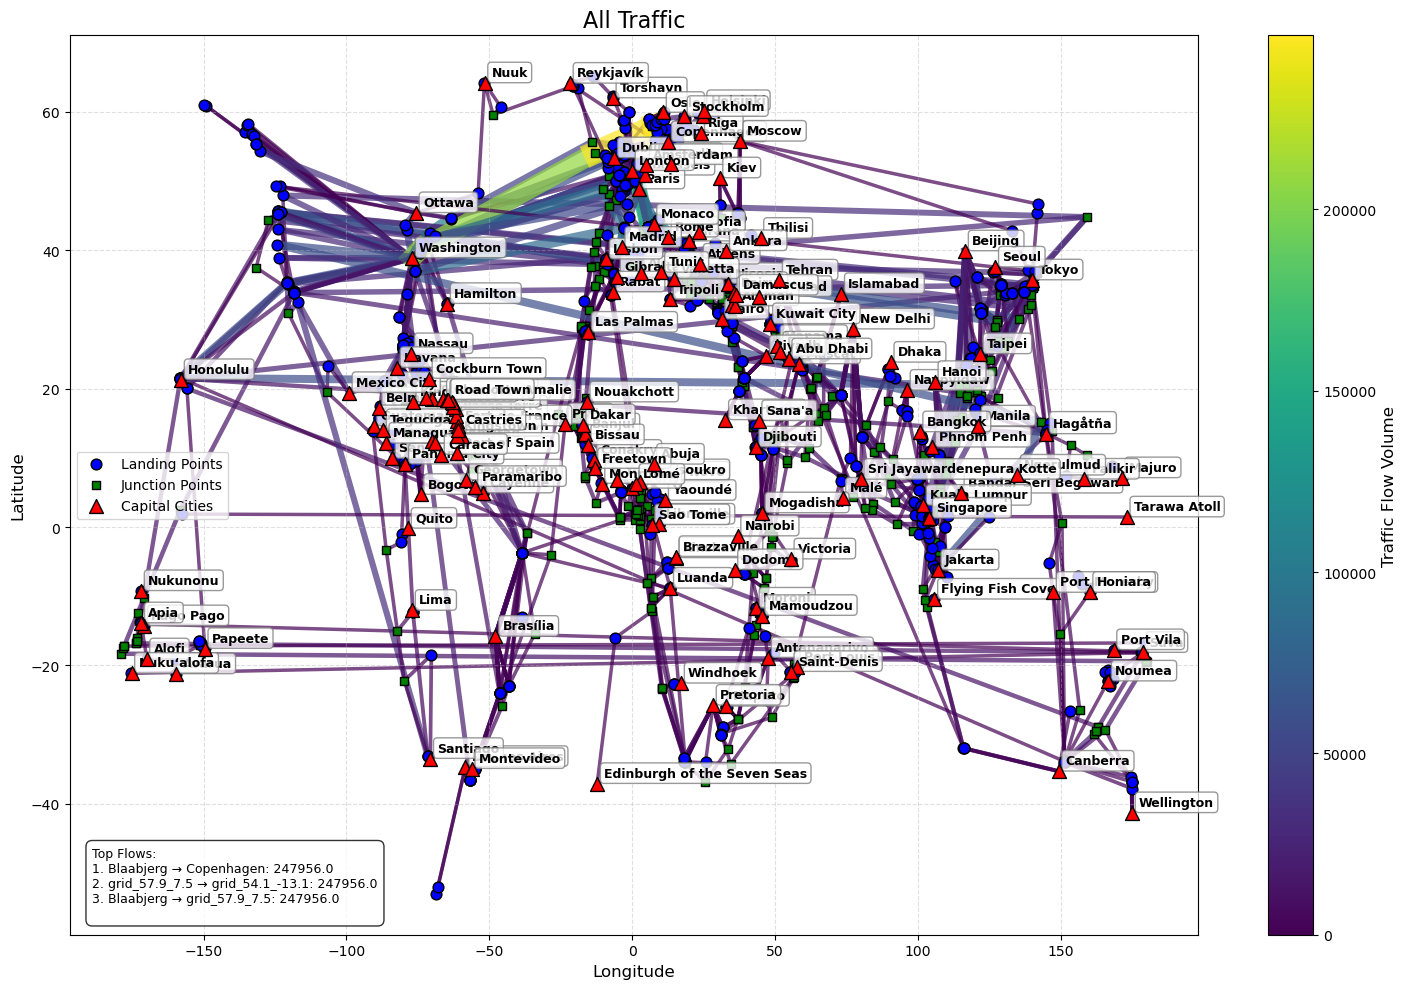

In [41]:
# Plot all traffic
plot_traffic(merged_data, nodes, traffic_col='traffic_all', title='All Traffic')

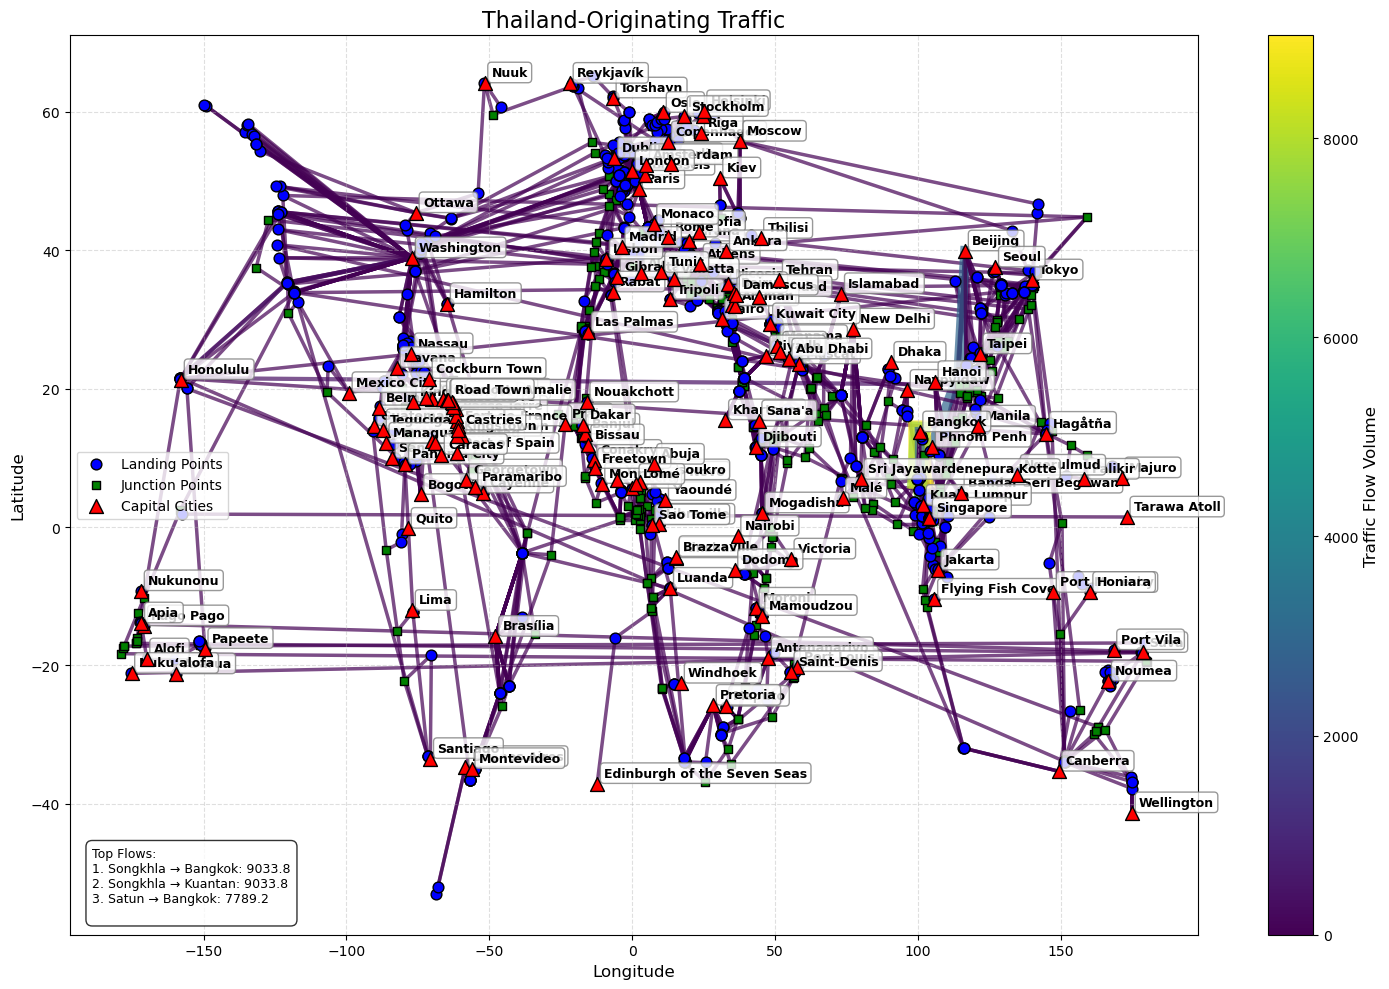

In [42]:
# Plot traffic for a specific country of interest
plot_traffic(merged_data, nodes, traffic_col='traffic_Thailand', title='Thailand-Originating Traffic')

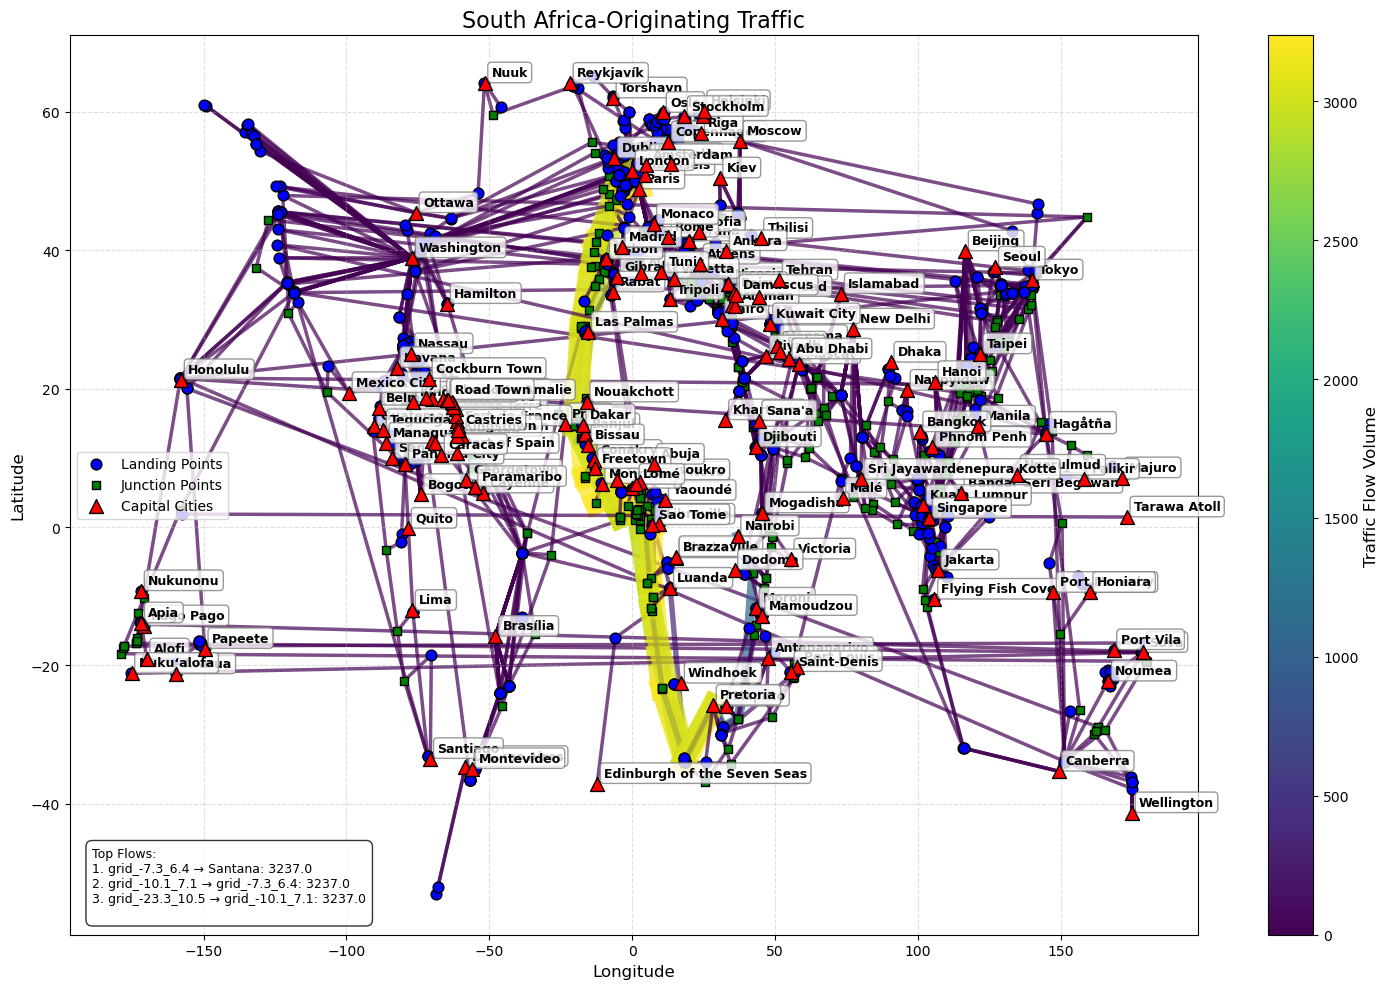

In [43]:
# Plot traffic for a specific country of interest
plot_traffic(merged_data, nodes, traffic_col='traffic_South_Africa', title='South Africa-Originating Traffic')